# Computing Realized Variance (RV)

**Source:** CSV file "EUROSTOXX50.csv" was cleaned using code "open_data_files.ipynb"

In [1]:
import pandas as pd 
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/EUROSTOXX50.csv"
df = pd.read_csv(file_path)

# Set "Date-Time-CET" and "Date" as timezone-aware datetimes
df["Date-Time-CET"] = pd.to_datetime(df["Date-Time-CET"], utc=True, errors="coerce").dt.tz_convert("Europe/Berlin")
df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce").dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date-Time-CET").set_index("Date-Time-CET")

df.head()

,Date,Last,Volume,No. Trades
Date-Time-CET,,,,
1998-02-20 13:47:00+01:00,1998-02-20 00:00:00+01:00,NaN,NaN,NaN
1998-02-20 13:48:00+01:00,1998-02-20 00:00:00+01:00,NaN,NaN,NaN
1998-02-20 13:49:00+01:00,1998-02-20 00:00:00+01:00,NaN,NaN,NaN
1998-02-20 13:50:00+01:00,1998-02-20 00:00:00+01:00,NaN,NaN,NaN
1998-02-20 13:51:00+01:00,1998-02-20 00:00:00+01:00,NaN,NaN,NaN


In [2]:
print(type(df.index))
print(df.index.dtype)
print(df[["Date", "Last"]].dtypes)
print(df.index[:3])

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
datetime64[ns, Europe/Berlin]
Date    datetime64[ns, Europe/Berlin]
Last                          float64
dtype: object
DatetimeIndex(['1998-02-20 13:47:00+01:00', '1998-02-20 13:48:00+01:00',
               '1998-02-20 13:49:00+01:00'],
              dtype='datetime64[ns, Europe/Berlin]', name='Date-Time-CET', freq=None)


In [3]:
# Roughly 3.07% of data contain NaN values in "Last column
df["Last"].isna().mean()

0.03070807471703744

## Construct 1-minute intraday log returns using observed prices

Let $P_{t,i}$ the EURO STOXX 50 index level at intraday minute $i$ on trading day $t$
We define the 1-minute log return as: 
$$
r_{t,i} = \log\!\left(P_{t,i}\right) - \log\!\left(P_{t,i-1}\right)
$$

where: 
* $i = 1,..., M_t$
* $M_t$ is the number of intraday observations during trading hours (09:00-17:29 CET). note that returns are computed within each trading day only, so overnight returns are exluded at this stage. 

In [6]:
import numpy as np

df["log_last"] = np.log(df["Last"])
df["r_1m"] = df["log_last"].groupby(df["Date"]).diff()
df[["Date", "Last", "r_1m"]].tail(10)

,Date,Last,r_1m
Date-Time-CET,,,
2020-08-07 17:20:00+02:00,2020-08-07 00:00:00+02:00,3251.88,0.000578
2020-08-07 17:21:00+02:00,2020-08-07 00:00:00+02:00,3251.70,-0.000055
2020-08-07 17:22:00+02:00,2020-08-07 00:00:00+02:00,3254.08,0.000732
2020-08-07 17:23:00+02:00,2020-08-07 00:00:00+02:00,3254.22,0.000043
2020-08-07 17:24:00+02:00,2020-08-07 00:00:00+02:00,3253.79,-0.000132
2020-08-07 17:25:00+02:00,2020-08-07 00:00:00+02:00,3252.60,-0.000366
2020-08-07 17:26:00+02:00,2020-08-07 00:00:00+02:00,3250.39,-0.000680
2020-08-07 17:27:00+02:00,2020-08-07 00:00:00+02:00,3250.42,0.000009
2020-08-07 17:28:00+02:00,2020-08-07 00:00:00+02:00,3247.75,-0.000822


### Computing Overnight Returns 

Define: 
* $P_t^{\text{open}}$: first observed trading on day $t$
* $P_{t-1}^{\text{close}}$: last observed trading price on day $t-1$

The overnight log return is: 
$$
r_t^{\text{overnight}} = \log\!\left(P_t^{\text{open}}\right) - \log\!\left(P_{t-1}^{\text{close}}\right)
$$

This measures the price jump occurring outisde regular trading hours$

In [9]:
# Construct dily open and daily closing prices 
daily_open = df.groupby("Date")["Last"].first()
daily_close = df.groupby("Date")["Last"].last()

daily_open.tail(), daily_close.tail()

(Date
 2020-08-03 00:00:00+02:00    3186.02
 2020-08-04 00:00:00+02:00    3270.71
 2020-08-05 00:00:00+02:00    3274.81
 2020-08-06 00:00:00+02:00    3257.99
 2020-08-07 00:00:00+02:00    3235.30
 Name: Last, dtype: float64,
 Date
 2020-08-03 00:00:00+02:00    3253.20
 2020-08-04 00:00:00+02:00    3251.94
 2020-08-05 00:00:00+02:00    3267.21
 2020-08-06 00:00:00+02:00    3244.07
 2020-08-07 00:00:00+02:00    3248.01
 Name: Last, dtype: float64)

In [10]:
# Small Cleaning Step
daily = pd.DataFrame({
    "Open": daily_open,
    "Close": daily_close
})

daily = daily.dropna()

daily.head()

,Open,Close
Date,,
1998-02-26 00:00:00+01:00,2862.67,2874.85
1998-02-27 00:00:00+01:00,2880.29,2879.47
1998-03-02 00:00:00+01:00,2880.22,2929.82
1998-03-03 00:00:00+01:00,2925.00,2908.40
1998-03-04 00:00:00+01:00,2912.19,2876.57


In [11]:
daily["log_open"] = np.log(daily["Open"])
daily["log_close"] = np.log(daily["Close"])

daily["r_overnight"] = daily["log_open"] - daily["log_close"].shift(1)

daily.head()

,Open,Close,log_open,log_close,r_overnight
Date,,,,,
1998-02-26 00:00:00+01:00,2862.67,2874.85,7.959510,7.963756,NaN
1998-02-27 00:00:00+01:00,2880.29,2879.47,7.965646,7.965362,0.001890
1998-03-02 00:00:00+01:00,2880.22,2929.82,7.965622,7.982696,0.000260
1998-03-03 00:00:00+01:00,2925.00,2908.40,7.981050,7.975358,-0.001647
1998-03-04 00:00:00+01:00,2912.19,2876.57,7.976661,7.964354,0.001302


## Intraday Realized Volatility 

Intraday realized variance for day $t$ is defined as: 

$$
RV_t^{\text{intra}} = \sum_{i=1}^{M_t} r_{t,i}^2
$$

This measure captures the total variation accumulated during regular trading hours

In [14]:
rv_intraday = df.groupby("Date")["r_1m"].apply(lambda x: np.nansum(x**2))
rv_intraday.tail()

Date
2020-08-03 00:00:00+02:00    0.000108
2020-08-04 00:00:00+02:00    0.000129
2020-08-05 00:00:00+02:00    0.000068
2020-08-06 00:00:00+02:00    0.000109
2020-08-07 00:00:00+02:00    0.000089
Name: r_1m, dtype: float64

In [15]:
daily["RV_intra"] = rv_intraday
daily.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra
Date,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089


## Adding Positive and Negative based RV for SHAR model 

##### Intraday

In [18]:
# --- Positive Intraday Semivariance ---
rv_intraday_pos = df.groupby("Date")["r_1m"].apply(
    lambda x: np.nansum((x[x > 0])**2)
)

# --- Negative Intraday Semivariance ---
rv_intraday_neg = df.groupby("Date")["r_1m"].apply(
    lambda x: np.nansum((x[x < 0])**2)
)

# Add to daily dataframe (without touching RV_intra)
daily["RV_intra_pos"] = rv_intraday_pos
daily["RV_intra_neg"] = rv_intraday_neg

##### Overnight 

In [20]:
# --- Positive Overnight Semivariance ---
daily["RV_overnight_pos"] = np.where(
    daily["r_overnight"] > 0,
    daily["r_overnight"]**2,
    0
)

# --- Negative Overnight Semivariance ---
daily["RV_overnight_neg"] = np.where(
    daily["r_overnight"] < 0,
    daily["r_overnight"]**2,
    0
)

daily.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg
Date,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007


## Total Realized Variance 

Following the methodology in Bekaert & Hoerova (2014), daily realized variance including overnight return is:

$$
RV_t^{\text{total}} = RV_t^{\text{intra}} + \left(r_t^{\text{overnight}}\right)^2
$$

This corresponds to close-to-close return variation and is directly comparable to implied variance measures such as the VSTOXX and VIX. 

In [23]:
daily["RV_overnight"] = daily["r_overnight"]**2
daily["RV_total"] = daily["RV_intra"] + daily["RV_overnight"]
daily.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total
Date,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097


In [24]:
#### For SHAR Model

In [25]:
# --- Total Positive Realized Semivariance ---
daily["RV_total_pos"] = (
    daily["RV_intra_pos"] +
    daily["RV_overnight_pos"]
)

# --- Total Negative Realized Semivariance ---
daily["RV_total_neg"] = (
    daily["RV_intra_neg"] +
    daily["RV_overnight_neg"]
)

daily.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total,RV_total_pos,RV_total_neg
Date,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109,0.000066,0.000043
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158,0.000087,0.000071
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117,0.000081,0.000036
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117,0.000052,0.000065
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097,0.000053,0.000043


## Realized Quarticity (RQ)

For intraday returns $r_{t,i}$ realized quarticity is defined as: 
$$
RQ_t = \frac{M_t}{3} \sum_{i=1}^{M_t} r_{t,i}^4
$$

where: 
* $M_t$ = umber of intraday returns on day $t$
* The caling factor $\frac{M_t}{3}$ ensures consistency under continuous semimartingale assumptions

RQ estimates the integrated quarticity ($IQ$), which captures the variability of volatility itself 

It is used in HARQ to scale the impacy of lagged realized variance 

In [28]:
# Computing RQ

# Number of intraday returns per day
M_t = df.groupby("Date")["r_1m"].count()

# Realized Quarticity
rq_daily = df.groupby("Date")["r_1m"].apply(
    lambda x: (len(x.dropna()) / 3) * np.nansum(x**4)
)

daily["RQ"] = rq_daily
daily.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total,RV_total_pos,RV_total_neg,RQ
Date,,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109,0.000066,0.000043,1.898579e-08
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158,0.000087,0.000071,2.613017e-08
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117,0.000081,0.000036,7.450015e-09
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117,0.000052,0.000065,1.545187e-08
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097,0.000053,0.000043,3.748493e-08


In [29]:
# Diagnostic check 
(daily["RQ"] / (daily["RV_intra"]**2)).describe()

count    5713.000000
mean        3.684020
std         5.033754
min         0.439413
25%         1.764869
50%         2.359820
75%         3.545382
max        98.658777
dtype: float64

Under ideal continuous semimartingale assumptions (no jumps, perfect sampling), the **theoretical ratio tends to be around 3**.

## Plotting the graph and observing outlier

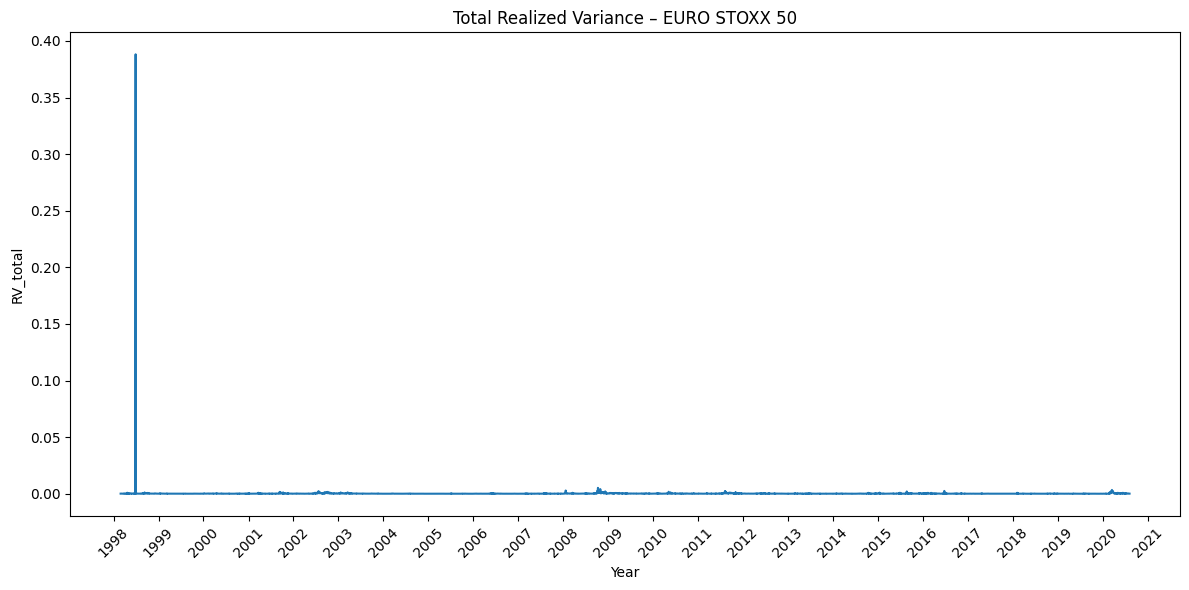

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(daily.index, daily["RV_total"])

plt.title("Total Realized Variance – EURO STOXX 50")
plt.xlabel("Year")
plt.ylabel("RV_total")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
daily["RV_total"].idxmax(), daily["RV_total"].max()

(Timestamp('1998-06-29 00:00:00+0200', tz='Europe/Berlin'), 0.3881760810158801)

In [34]:
daily["RV_total"].sort_values(ascending=False).head(3)

Date
1998-06-29 00:00:00+02:00    0.388176
2008-10-10 00:00:00+02:00    0.005199
2008-10-29 00:00:00+01:00    0.004071
Name: RV_total, dtype: float64

In [35]:
# Overview of the day on the 29th of June 1998
daily.loc["1998-06-29"]

Open                6.329700e+03
Close               3.430240e+03
log_open            8.753008e+00
log_close           8.140386e+00
r_overnight         6.229638e-01
RV_intra            9.217456e-05
RV_intra_pos        4.681403e-05
RV_intra_neg        4.536053e-05
RV_overnight_pos    3.880839e-01
RV_overnight_neg    0.000000e+00
RV_overnight        3.880839e-01
RV_total            3.881761e-01
RV_total_pos        3.881307e-01
RV_total_neg        4.536053e-05
RQ                  9.166665e-08
Name: 1998-06-29 00:00:00+02:00, dtype: float64

In [36]:
# Removing days with overnight returns above 0.1 (abnormally large overnight return)

threshold = 0.10

mask = daily["r_overnight"].abs().le(threshold) | daily["r_overnight"].isna()
daily_clean = daily[mask].copy()

## Additional information for LogHAR, LevHAR, and SHAR

In [38]:
# Daily close-to-close return
daily_clean["r_daily"] = (
    np.log(daily_clean["Close"]) -
    np.log(daily_clean["Close"].shift(1))
)

# Computing log_RV_total and log_RV_intra (not used) for LogHAR model
daily_clean["log_RV_total"] = np.log(daily_clean["RV_total"])
daily_clean["log_RV_intra"] = np.log(daily_clean["RV_intra"])
daily_clean.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total,RV_total_pos,RV_total_neg,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109,0.000066,0.000043,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158,0.000087,0.000071,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117,0.000081,0.000036,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117,0.000052,0.000065,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097,0.000053,0.000043,3.748493e-08,0.001214,-9.243673,-9.322462


## Plot without outlier

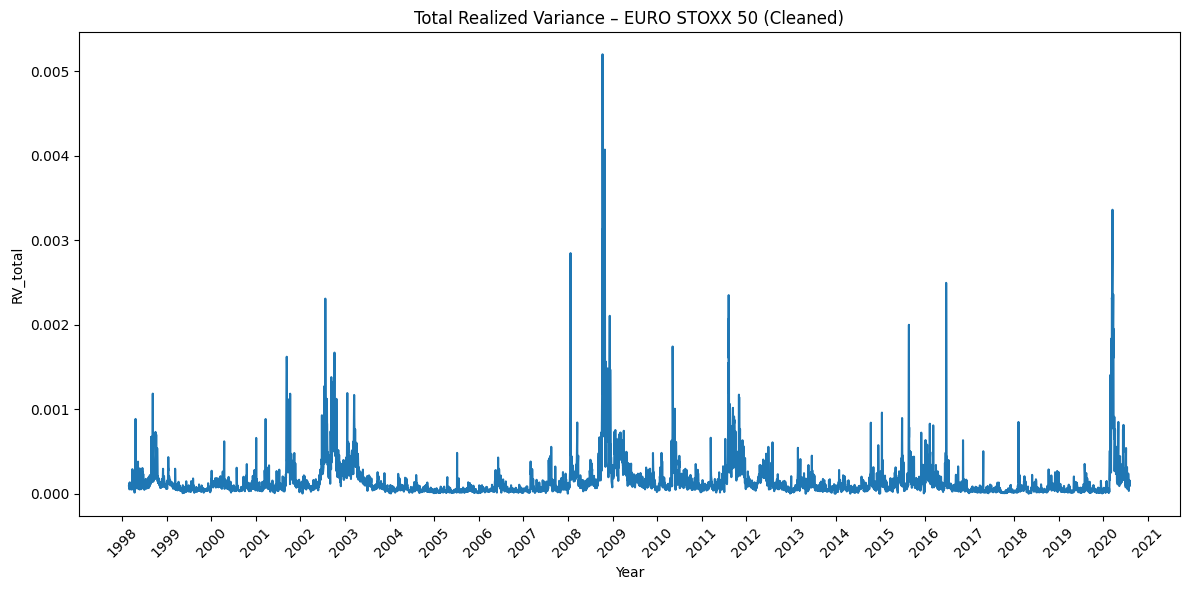

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(daily_clean.index, daily_clean["RV_total"])

plt.title("Total Realized Variance – EURO STOXX 50 (Cleaned)")
plt.xlabel("Year")
plt.ylabel("RV_total")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plot yearly box plot for daily volatility

/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_43153/2918023042.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years, showfliers=False)


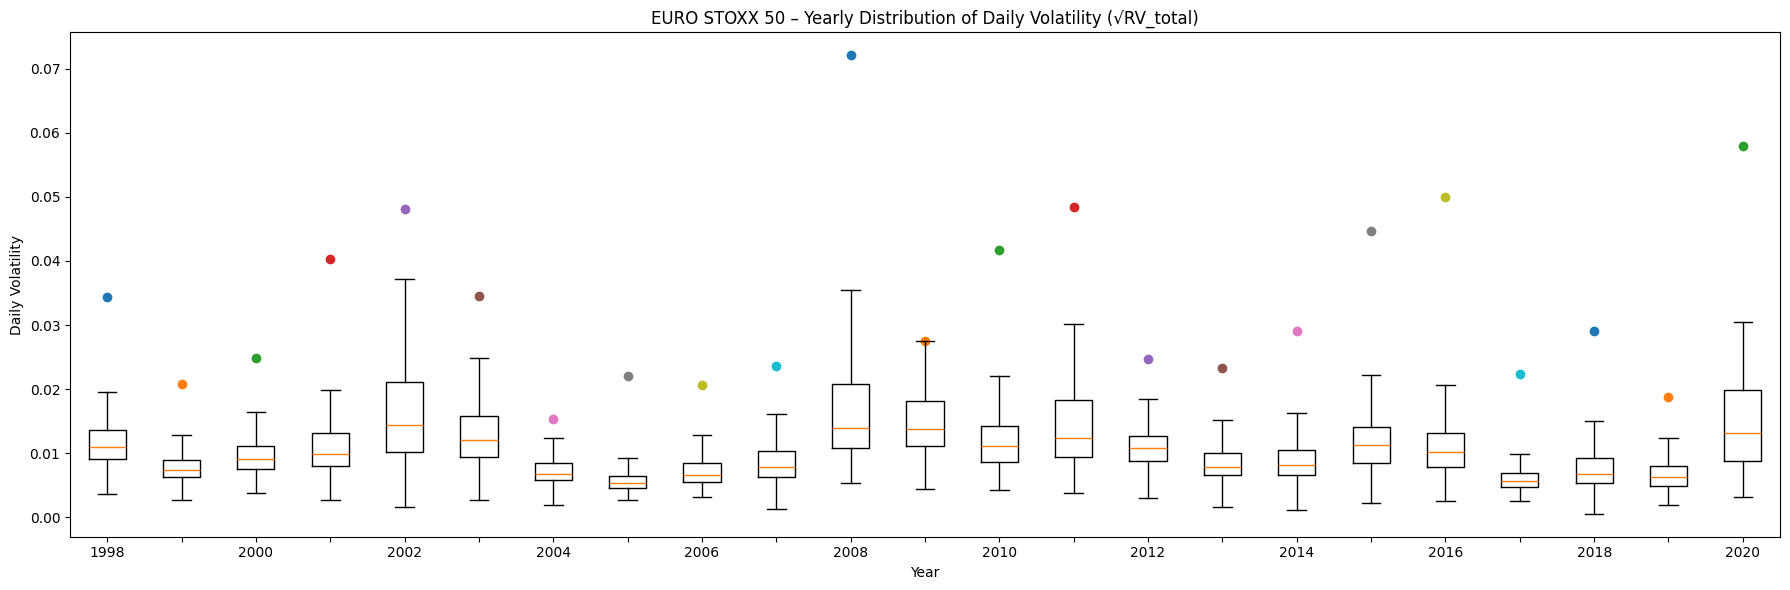

In [43]:
# Create volatility measure
tmp = daily_clean[["RV_total"]].copy()
tmp["Volatility"] = np.sqrt(tmp["RV_total"])
tmp["Year"] = tmp.index.year

years = sorted(tmp["Year"].unique())
data = [tmp.loc[tmp["Year"] == y, "Volatility"].dropna().values for y in years]

plt.figure(figsize=(18, 6))

# Boxplots without default outliers
plt.boxplot(data, labels=years, showfliers=False)

# Highlight yearly maximum volatility
for i, y in enumerate(years):
    yearly_max = tmp.loc[tmp["Year"] == y, "Volatility"].max()
    plt.scatter(i + 1, yearly_max)

plt.title("EURO STOXX 50 – Yearly Distribution of Daily Volatility (√RV_total)")
plt.xlabel("Year")
plt.ylabel("Daily Volatility")

# Reduce label crowding
ax = plt.gca()
for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

## Final Output Stored in CSV file 

In [52]:
output_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
daily_clean.to_csv(output_path, index=True)

## Graphs for LaTeX Document

#### Line Chart - Realized Variance 

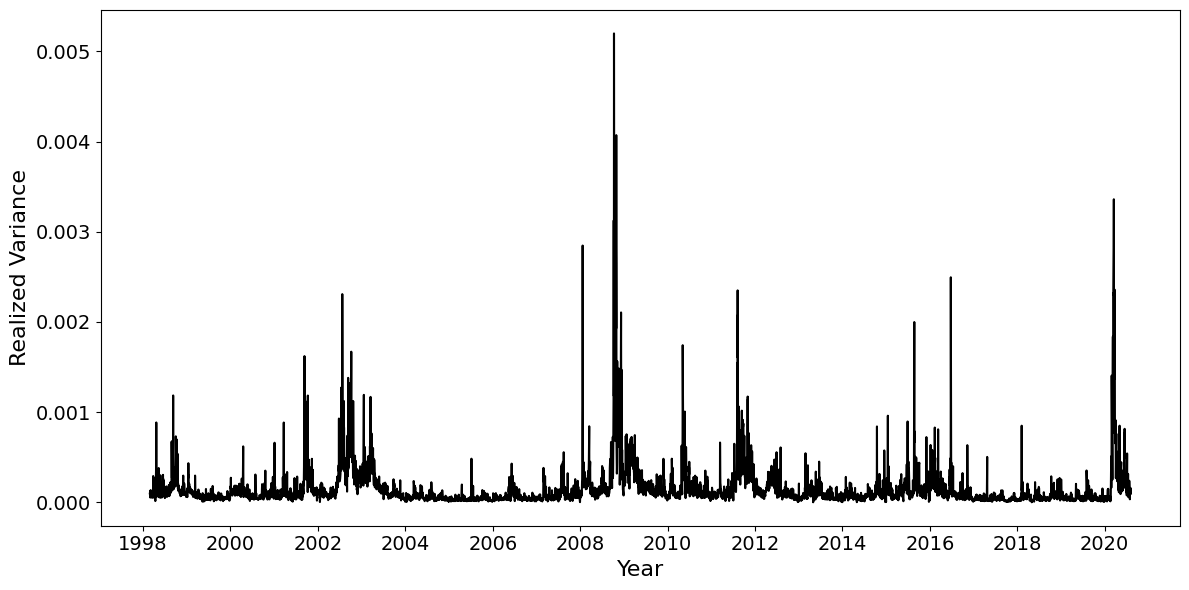

In [57]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- SAVE LOCATION ----
FIG_DIR = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures"
os.makedirs(FIG_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(
    daily_clean.index,
    daily_clean["RV_total"],
    color="black"
)

# Axis labels (consistent sizing with boxplot)
ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Realized Variance", fontsize=16)

# Tick label size
ax.tick_params(axis="both", labelsize=14)

# 2-year ticks
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# NOTE: We DO NOT remove top/right spines here

fig.tight_layout()

# ---- Save as vector PDF ----
fig.savefig(
    os.path.join(FIG_DIR, "rv_total_eurostoxx50_1998_2020.pdf"),
    bbox_inches="tight"
)

plt.show()

#### Box plot - Realized Variance 

/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_43153/2360178413.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


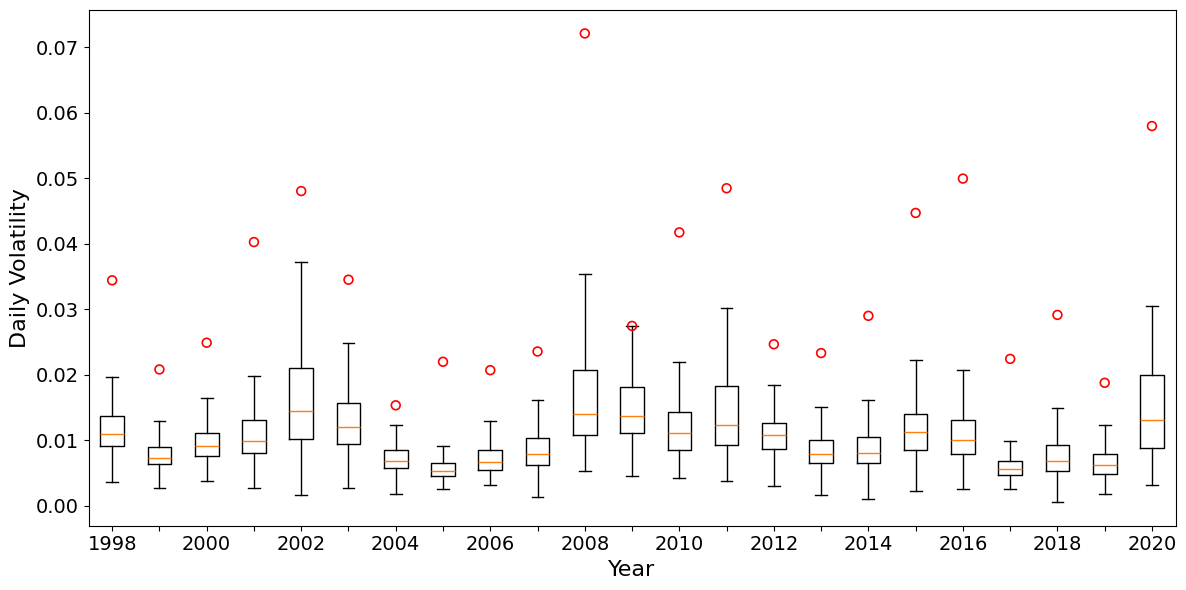

In [72]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- SAVE LOCATION ----
FIG_DIR = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Figures"
os.makedirs(FIG_DIR, exist_ok=True)

tmp = daily_clean[["RV_total"]].copy()
tmp["Volatility"] = np.sqrt(tmp["RV_total"])
tmp["Year"] = tmp.index.year

years = sorted(tmp["Year"].unique())
data = [tmp.loc[tmp["Year"] == y, "Volatility"].dropna().values for y in years]

# IMPORTANT: match the line chart figure size so LaTeX scaling is identical
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplots WITHOUT default outliers
ax.boxplot(
    data,
    labels=years,
    showfliers=False
)

# Plot ONLY yearly maximum volatility (white fill, red outline)
for i, y in enumerate(years):
    yearly_data = tmp.loc[tmp["Year"] == y, "Volatility"].dropna()
    if len(yearly_data) > 0:
        yearly_max = yearly_data.max()
        ax.scatter(
            i + 1,
            yearly_max,
            facecolors="none",
            edgecolors="red",
            s=40,
            linewidths=1.2,
            zorder=3
        )

# Axis titles + tick labels (match line chart)
ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Daily Volatility", fontsize=16)
ax.tick_params(axis="both", labelsize=14)

# Reduce label crowding (hide every other year label)
for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0:
        label.set_visible(False)

fig.tight_layout()

# ---- Save as vector PDF (LaTeX-ready) ----
fig.savefig(
    os.path.join(FIG_DIR, "box_plot_sqrt__rv.pdf"),
    bbox_inches="tight"
)

plt.show()

In [79]:
# Maximum RV_total in 2001
peak_2001_date = daily_clean.loc["2001", "RV_total"].idxmax()
peak_2001_value = daily_clean.loc["2001", "RV_total"].max()

print("Date:", peak_2001_date)
print("RV_total:", peak_2001_value)

Date: 2001-09-11 00:00:00+02:00
RV_total: 0.0016210289696903606


In [81]:
# Maximum RV_total in 2020
peak_2020_date = daily_clean.loc["2020", "RV_total"].idxmax()
peak_2020_value = daily_clean.loc["2020", "RV_total"].max()

print("Date:", peak_2020_date)
print("RV_total:", peak_2020_value)

Date: 2020-03-17 00:00:00+01:00
RV_total: 0.0033601015271935487
